<a href="https://colab.research.google.com/github/AjMing/Pattern-EGCI463/blob/main/Week9/KERAS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
import numpy as np


In [31]:
#Define the model achitecture
model = Sequential()
model.add(Dense(512, input_shape=(784,),activation='relu')) #first hidden layer
model.add(Dropout(0.2)) # don't back propergate all the time, stop weight from fluctuation from all input
#model.add(Dense(512,activation='relu'))
#model.add(Dropout(0.2))
#model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))
model.summary()
#Softmax => logistic --> (out)/sum(output) -> Probabilities. --> 0 -->1

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
import pandas as pd

In [33]:
from google.colab import drive
drive.mount("/content/drive",force_remount=True)
path="/content/drive/My Drive/data/digit.csv"
df =pd.read_csv(path)
data=pd.read_csv(path,header=None)

Mounted at /content/drive


In [34]:
data

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [35]:
X=data.values

In [53]:
from sklearn.model_selection import train_test_split
X_train , X_test, Y_train, Y_test=train_test_split(X[:,:-1],X[:,-1],test_size=0.2)

In [54]:
print(Y_train.shape)
print(Y_train)

(400,)
[7 2 8 9 9 4 9 1 6 3 4 3 4 2 0 5 8 1 6 9 0 4 6 1 8 5 9 6 7 3 2 8 1 4 0 9 7
 9 2 7 3 7 9 7 2 2 7 0 2 8 9 6 9 3 8 1 0 2 7 4 7 6 9 8 5 7 1 5 4 8 4 1 7 4
 2 5 5 6 7 9 2 1 2 9 9 4 1 9 5 0 8 7 2 3 0 6 0 3 8 1 7 8 3 9 5 6 2 7 7 2 2
 1 4 1 8 0 8 4 9 8 1 7 8 3 0 5 7 6 3 7 1 5 5 4 3 2 7 6 6 0 5 8 6 7 5 6 9 5
 6 9 6 3 3 3 3 1 8 7 8 5 5 6 6 4 9 0 5 5 0 4 1 4 0 2 3 8 1 2 6 1 0 4 1 3 2
 8 1 4 4 0 4 9 1 1 8 7 6 0 4 1 5 7 2 9 0 9 3 1 2 6 5 4 0 5 4 6 2 2 7 2 5 5
 4 8 3 4 2 9 1 3 4 0 5 4 8 3 8 1 7 4 4 0 4 3 8 3 6 8 6 5 8 0 5 3 2 8 0 4 4
 8 1 2 5 1 1 7 3 3 5 4 2 4 1 0 0 6 2 8 9 6 0 1 6 9 4 4 1 2 1 4 9 9 2 3 6 9
 6 7 4 3 3 3 3 3 7 6 3 9 7 1 7 0 5 6 7 7 8 6 4 1 9 9 8 5 5 4 7 7 2 5 4 7 0
 7 0 2 8 3 0 5 1 9 8 9 9 6 6 7 8 0 3 3 8 8 3 0 6 2 4 1 0 0 1 4 6 1 9 9 5 1
 9 5 3 1 2 7 6 2 6 7 9 7 0 2 3 7 8 6 5 4 6 7 0 6 6 5 8 0 9 8]


In [38]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])
#Make the model learn
#MORE OPTIMIZER DETAILS here https://keras.io/optimizers/

In [39]:
from keras.utils import to_categorical
# do one hot encoding
y_train = keras.utils.to_categorical(Y_train, num_classes=10)
y_test = keras.utils.to_categorical(Y_test, num_classes=10)


In [52]:
print(y_train.shape)
print(y_train)

(400, 10)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


In [41]:
print(y_test)

[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0.

In [42]:
history=model.fit(X_train, y_train, epochs=200, verbose=1,validation_data=(X_test, y_test))


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3070 - loss: 103.1031 - val_accuracy: 0.8000 - val_loss: 20.1780
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7333 - loss: 23.0831 - val_accuracy: 0.7800 - val_loss: 23.7673
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9099 - loss: 5.5917 - val_accuracy: 0.8200 - val_loss: 20.7291
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9166 - loss: 2.5689 - val_accuracy: 0.9000 - val_loss: 15.3559
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9804 - loss: 1.0277 - val_accuracy: 0.8800 - val_loss: 15.3527
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9593 - loss: 1.2590 - val_accuracy: 0.8800 - val_loss: 16.3440
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9871 - loss: 0.3314 - val_accuracy: 0.8700 - val_loss: 18.2819
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9797 - loss: 0.8876 - val_ac

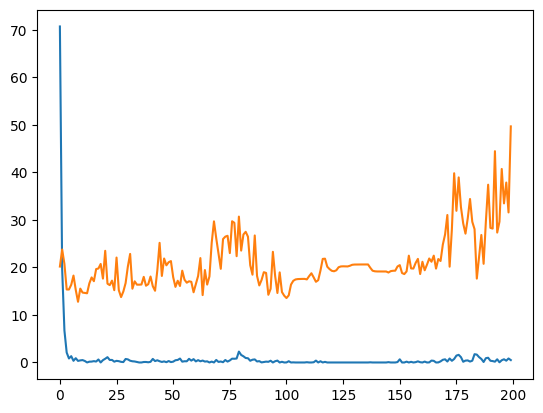

In [43]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

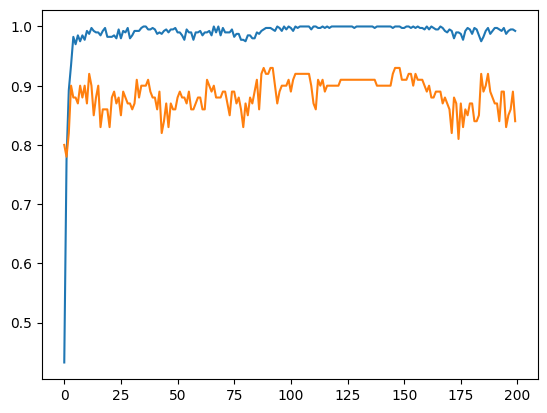

In [44]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [45]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=["accuracy"])


In [46]:
X_tests=X_test/255
X_trains=X_train/255

In [47]:
history=model.fit(X_trains, y_train, epochs=200, verbose=1,validation_data=(X_tests, y_test))


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9927 - loss: 0.2566 - val_accuracy: 0.9000 - val_loss: 0.3909
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0457 - val_accuracy: 0.9000 - val_loss: 0.4048
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9990 - loss: 0.0197 - val_accuracy: 0.9100 - val_loss: 0.4082
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.9100 - val_loss: 0.4103
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.9100 - val_loss: 0.4132
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0076 - val_accuracy: 0.9000 - val_loss: 0.4159
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9000 - val_loss: 0.4198
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.

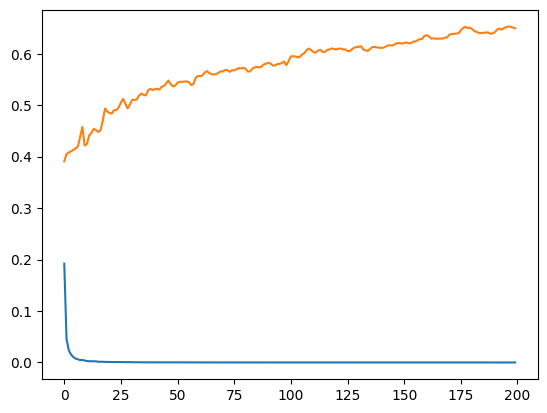

In [48]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [49]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_train)
Y_pred = np.argmax(y_pred, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_train, Y_pred))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_train, Y_pred, target_names=target_names))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Confusion Matrix
[[35  0  0  0  0  0  0  0  0  0]
 [ 0 41  0  0  0  0  0  0  0  0]
 [ 0  0 44  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  0  0  0  0  0]
 [ 0  0  0  0 40  0  0  0  0  0]
 [ 0  0  0  0  0 45  0  0  0  0]
 [ 0  0  0  0  0  0 38  0  0  0]
 [ 0  0  0  0  0  0  0 44  0  0]
 [ 0  0  0  0  0  0  0  0 36  0]
 [ 0  0  0  0  0  0  0  0  0 41]]
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        44
           3       1.00      1.00      1.00        36
           4       1.00      1.00      1.00        40
           5       1.00      1.00      1.00        45
           6       1.00      1.00      1.00        38
           7       1.00      1.00      1.00        44
           8       1.00      1.00      1.00        36
           9       1.00      1.00      1.00      

In [50]:

y_pred_test = model.predict(X_test)
Y_pred_test = np.argmax(y_pred_test, axis=1)
print('Confusion Matrix')
print(confusion_matrix(Y_test, Y_pred_test))
print('Classification Report')
target_names = ['0', '1', '2','3', '4', '5', '6', '7', '8', '9']
print(classification_report(Y_test, Y_pred_test, target_names=target_names))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Confusion Matrix
[[15  0  0  0  0  0  0  0  0  0]
 [ 0  9  0  0  0  0  0  0  0  0]
 [ 0  0  6  0  0  0  0  0  0  0]
 [ 0  0  1 12  0  0  0  0  0  1]
 [ 0  0  0  0 10  0  0  0  0  0]
 [ 1  0  0  0  0  4  0  0  0  0]
 [ 0  2  0  0  0  0 10  0  0  0]
 [ 0  0  0  0  0  0  0  6  0  0]
 [ 0  1  0  1  0  1  0  0 11  0]
 [ 1  0  0  0  0  0  0  0  0  8]]
Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       0.75      1.00      0.86         9
           2       0.86      1.00      0.92         6
           3       0.92      0.86      0.89        14
           4       1.00      1.00      1.00        10
           5       0.80      0.80      0.80         5
           6       1.00      0.83      0.91        12
           7       1.00      1.00      1.00         6
           8       1.00      0.79      0.88        14
           9       0.89      0.89      0.89        

In [51]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)